In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1. Cargar la base
df = pd.read_csv('df_long.csv')

# 2. Filtrar para tener solo un dato por sujeto (evitar inflación de N)
# Esto selecciona la primera aparición de cada sujeto
df_u = df.drop_duplicates(subset=['ID_Sujeto']).copy()

# 3. Distribución de Variables Clave (Histogramas)
vars_clave = ['expectativa_sin', 'expectativa_pequeña', 'expectativa_grande']

plt.figure(figsize=(15, 5)) # Una fila, tres columnas

for i, var in enumerate(vars_clave):
    plt.subplot(1, 3, i+1)
    
    # Usamos discrete=True porque los valores son -1, 0, 1
    sns.histplot(df_u[var], discrete=True, kde=False, color='skyblue', shrink=0.8)
    
    plt.xticks([-1, 0, 1])
    plt.title(f'Distribución de {var}\n(Sujetos Únicos, N={len(df_u)})')
    plt.xlabel('Valor (-1 (revierte), 0 (cree que no afecta), 1(mantiene))')
    plt.ylabel('Frecuencia (Sujetos)')

plt.tight_layout()
plt.show()



# 1. Cargar datos y filtrar sujetos únicos
n_total = len(df_u)

# 2. Definir las variables clave
vars_clave = ['expectativa_sin', 'expectativa_pequeña', 'expectativa_grande']

# 3. Crear un diccionario para consolidar los datos
resumen_datos = {}

for var in vars_clave:
    # Contamos frecuencias
    conteos = df_u[var].value_counts().reindex([-1, 0, 1], fill_value=0)
    # Calculamos porcentajes
    porcentajes = (conteos / n_total * 100).round(1)
    
    # Combinamos ambos en un formato "N (%)" para una lectura rápida
    resumen_datos[var] = [f"{n} ({p}%)" for n, p in zip(conteos, porcentajes)]

# 4. Crear el DataFrame final
tabla_final = pd.DataFrame(resumen_datos, index=[-1, 0, 1])
tabla_final.index.name = 'Opción'

print(f"Resumen de Expectativas (N Total = {n_total})")
print(tabla_final)

In [ ]:
# Calcular la Tasa de Mantiene promedio por sujeto (para que 'Mantiene' sea una tasa real y no un 0/1 aleatorio)
tasa_sujeto = df.groupby('ID_Sujeto')['Mantiene'].mean()

# Crear base de sujetos únicos
df_u = df.drop_duplicates(subset=['ID_Sujeto']).set_index('ID_Sujeto').copy()
# Asignar la tasa calculada a la columna 'Mantiene'
df_u['Mantiene'] = tasa_sujeto
df_u = df_u.reset_index()

# Lista de variables a analizar
vars_exp = ['expectativa_sin_num', 'expectativa_pequeña_num', 'expectativa_grande_num']
titulos = ['Expectativa SIN G4P', 'Expectativa G4P PEQUEÑA', 'Expectativa G4P GRANDE']

# 2. Configurar la figura (3 subplots en una fila)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
sns.set_theme(style="whitegrid")

tablas_resumen = []

for i, var in enumerate(vars_exp):
    # CORRECCIÓN 1: NO filtramos los 0. Usamos todo el df_u.
    df_temp = df_u.copy()
    
    # CORRECCIÓN 2: Usamos errorbar='se' (Standard Error) en lugar de 'sd'
    sns.barplot(ax=axes[i], data=df_temp, x=var, y='Mantiene', 
                errorbar='se', capsize=.1, palette='coolwarm', alpha=0.7)
    
    # Agregar puntos individuales (dispersión)
    sns.stripplot(ax=axes[i], data=df_temp, x=var, y='Mantiene', 
                  color='black', alpha=0.3, jitter=True)
    
    axes[i].set_title(titulos[i], fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Tasa de Mantiene Promedio' if i==0 else "")
    axes[i].set_xlabel('Respuesta (-1: Revierte | 0: Neutro | 1: Mantiene)')
    axes[i].set_ylim(0, 1.1)
    
    # Guardar datos para la tabla resumen (Calculando SEM)
    resumen = df_temp.groupby(var)['Mantiene'].agg(['count', 'mean', 'sem']).reset_index()
    resumen.columns = ['Valor', 'N', 'Media', 'SEM']
    resumen['Tipo'] = titulos[i]
    tablas_resumen.append(resumen)

plt.tight_layout()
plt.savefig('graficos_expectativas_con_neutros_sem.png')

# 3. Mostrar las tablas resumen
print("--- TABLAS RESUMEN DE EXPECTATIVAS (INCLUYENDO 0 Y SEM) ---")
for t in tablas_resumen:
    print(f"\n{t['Tipo'].iloc[0]}:")
    print(t[['Valor', 'N', 'Media', 'SEM']].round(3).to_string(index=False))

In [ ]:

# --- LIMPIEZA DE DUPLICADOS EN df_long ---
df_long = df_long.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()

# 2. Preprocesamiento
df_long['Tratamiento'] = df_long['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# Definir columna de agrupación
col_grupo = 'expectativa_sin_num'

# Verificar que la columna exista
if col_grupo not in df_long.columns:
    print(f"Error: {col_grupo} no está en df_long")
else:
    grupos = sorted(df_long[col_grupo].dropna().unique())
    print(f"Grupos encontrados en {col_grupo}: {grupos}")

    # Iterar por cada grupo
    for grupo in grupos:
        print(f"\n{'='*80}")
        print(f" ANÁLISIS PARA: {col_grupo} = {grupo}")
        print(f"{'='*80}")
        
        # Filtrar df_long para este grupo
        df_long_grupo = df_long[df_long[col_grupo] == grupo].copy()
        ids_grupo = df_long_grupo['ID_Sujeto'].unique()
        
        # Filtrar df_resumen para los mismos sujetos (para consistencia)
        df_resumen_grupo = df_resumen[df_resumen['ID_Sujeto'].isin(ids_grupo)].copy()
        
        # --- PREPARACIÓN DE DATOS ---
        
        # A. Panel 1: Promedio General (Desde df_resumen)
        # Melt
        df_panel1 = df_resumen_grupo.melt(
            id_vars='ID_Sujeto', 
            value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
            var_name='Tratamiento', 
            value_name='Mantiene'
        )
        df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')
        
        # B. Panel 2: Promedio Primer Tratamiento (Desde df_long)
        df_panel2 = df_long_grupo[df_long_grupo['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento'])['Mantiene'].mean().reset_index()
        
        # --- VISUALIZACIÓN ---
        orden = ['CON', 'SIN', 'DIST']
        sns.set_theme(style="whitegrid")
        
        # Configuramos solo 2 columnas
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Panel 1
        sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, 
                    palette='Set2', errorbar='se', capsize=.1, ax=axes[0])
        sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, 
                      color='black', alpha=0.15, jitter=True, ax=axes[0])
        axes[0].set_title(f'1. Promedio General (Grupo {grupo})\n(I.S)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Tasa Mantiene')
        axes[0].set_ylim(0, 1.1)
        
        # Panel 2
        sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, 
                    palette='Set2', errorbar='se', capsize=.1, ax=axes[1])
        sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, 
                      color='black', alpha=0.3, jitter=True, ax=axes[1])
        axes[1].set_title(f'2. Promedio Primer Bloque (Grupo {grupo})\n(E.S)', fontsize=12, fontweight='bold', color='darkblue')
        axes[1].set_ylabel('')
        axes[1].set_ylim(0, 1.1)
        
        plt.suptitle(f'Efecto Tratamiento por Expectativa SIN = {grupo}', fontsize=16, y=1.05)
        plt.tight_layout()
        filename = f'panel_doble_expsin_{grupo}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        # --- TABLAS ---
        print(f"--- RESULTADOS GRUPO {grupo} ---")
        print("\n1. Intra-sujetos (Resumen):")
        print(df_panel1.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))
        
        print("\n2. Entre-sujetos (Primer Bloque):")
        print(df_panel2.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))
        print("\n")

In [ ]:
# 1. Load Data
df_long = pd.read_csv('df_long.csv')
df_resumen = pd.read_csv('Base_Resumen_Sujetos.csv')

# 2. Clean Duplicates in df_long
df_long = df_long.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()
df_long['Tratamiento'] = df_long['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# 3. Define Grouping Column
col_grupo = 'expectativa_sin_num'

# Check existence
if col_grupo not in df_long.columns:
    print(f"Error: {col_grupo} missing.")
else:
    grupos = sorted(df_long[col_grupo].dropna().unique())
    print(f"Groups: {grupos}")

    # --- CALCULATION ---
    
    # Store results
    results_intra = []
    results_inter = []

    for g in grupos:
        # Filter subjects for this group
        ids_grupo = df_long[df_long[col_grupo] == g]['ID_Sujeto'].unique()
        
        # A. INTRA-SUBJECT (From df_resumen)
        # Filter df_resumen
        df_res_g = df_resumen[df_resumen['ID_Sujeto'].isin(ids_grupo)].copy()
        
        # Calculate individual difference
        # Assuming columns exist. If not, we might need to recreate them from df_long intra logic, 
        # but df_resumen usually has Promedio_CON/SIN
        if 'Promedio_CON' in df_res_g.columns and 'Promedio_SIN' in df_res_g.columns:
            df_res_g['Diff_CON_SIN'] = df_res_g['Promedio_CON'] - df_res_g['Promedio_SIN']
            
            mean_diff = df_res_g['Diff_CON_SIN'].mean()
            sem_diff = df_res_g['Diff_CON_SIN'].sem()
            count = df_res_g['Diff_CON_SIN'].count()
            
            results_intra.append({
                'Expectativa': g,
                'Mean_Diff': mean_diff,
                'SEM_Diff': sem_diff,
                'Count': count
            })
        
        # B. BETWEEN-SUBJECT (From df_long, First Block)
        # Filter df_long
        df_long_g = df_long[(df_long[col_grupo] == g) & (df_long['Orden_1'] == 1)].copy()
        
        # Calculate group means per treatment
        stats = df_long_g.groupby(['ID_Sujeto', 'Tratamiento'])['Mantiene'].mean().reset_index()
        group_stats = stats.groupby('Tratamiento')['Mantiene'].agg(['mean', 'sem', 'count'])
        
        if 'CON' in group_stats.index and 'SIN' in group_stats.index:
            mean_con = group_stats.loc['CON', 'mean']
            mean_sin = group_stats.loc['SIN', 'mean']
            se_con = group_stats.loc['CON', 'sem']
            se_sin = group_stats.loc['SIN', 'sem']
            
            # Difference of means
            diff_means = mean_con - mean_sin
            # SE of difference (independent samples)
            se_diff = np.sqrt(se_con**2 + se_sin**2)
            
            results_inter.append({
                'Expectativa': g,
                'Mean_Diff': diff_means,
                'SEM_Diff': se_diff,
                'Count_CON': group_stats.loc['CON', 'count'],
                'Count_SIN': group_stats.loc['SIN', 'count']
            })

    df_res_intra = pd.DataFrame(results_intra)
    df_res_inter = pd.DataFrame(results_inter)

    # --- VISUALIZATION ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Plot 1: Intra
    sns.barplot(data=df_res_intra, x='Expectativa', y='Mean_Diff', palette='coolwarm', ax=axes[0])
    axes[0].errorbar(x=range(len(df_res_intra)), y=df_res_intra['Mean_Diff'], 
                     yerr=df_res_intra['SEM_Diff'], fmt='none', c='black', capsize=5)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Diferencia Intra-Sujetos (CON - SIN)\n(Promedio de diferencias individuales)', fontweight='bold')
    axes[0].set_ylabel('Diferencia Tasa Mantiene (CON - SIN)')
    axes[0].set_xlabel('Nivel de Expectativa (SIN)')
    
    # Add values
    for i, row in df_res_intra.iterrows():
        axes[0].text(i, row['Mean_Diff'] + (0.02 if row['Mean_Diff']>0 else -0.05), 
                     f"{row['Mean_Diff']:.3f}", ha='center', color='black', fontweight='bold')

    # Plot 2: Inter
    sns.barplot(data=df_res_inter, x='Expectativa', y='Mean_Diff', palette='coolwarm', ax=axes[1])
    axes[1].errorbar(x=range(len(df_res_inter)), y=df_res_inter['Mean_Diff'], 
                     yerr=df_res_inter['SEM_Diff'], fmt='none', c='black', capsize=5)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Diferencia Entre-Sujetos (CON - SIN)\n(Diferencia de medias grupales - Primer Bloque)', fontweight='bold')
    axes[1].set_xlabel('Nivel de Expectativa (SIN)')
    
    # Add values
    for i, row in df_res_inter.iterrows():
        axes[1].text(i, row['Mean_Diff'] + (0.02 if row['Mean_Diff']>0 else -0.05), 
                     f"{row['Mean_Diff']:.3f}", ha='center', color='black', fontweight='bold')

    plt.suptitle('Diferencia en Tasa de Mantiene (CON vs SIN) por Expectativa', fontsize=16)
    plt.tight_layout()
    plt.savefig('diferencia_con_sin_expectativas.png', dpi=300)
    plt.show()

    # Print Tables
    print("\n--- TABLA 1: DIFERENCIAS INTRA-SUJETOS (CON - SIN) ---")
    print(df_res_intra[['Expectativa', 'Mean_Diff', 'SEM_Diff', 'Count']].round(3))
    
    print("\n--- TABLA 2: DIFERENCIAS ENTRE-SUJETOS (CON - SIN) ---")
    print(df_res_inter[['Expectativa', 'Mean_Diff', 'SEM_Diff', 'Count_CON', 'Count_SIN']].round(3))

Mediana NDC Score: 4.666666666666667
Clasificación NDC completada.
Low NDC     70
High NDC    48
Name: NDC_Group, dtype: int64
Grupos encontrados en expectativa_sin_num: [-1, 0, 1]

 ANÁLISIS PARA: expectativa_sin_num = -1


C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


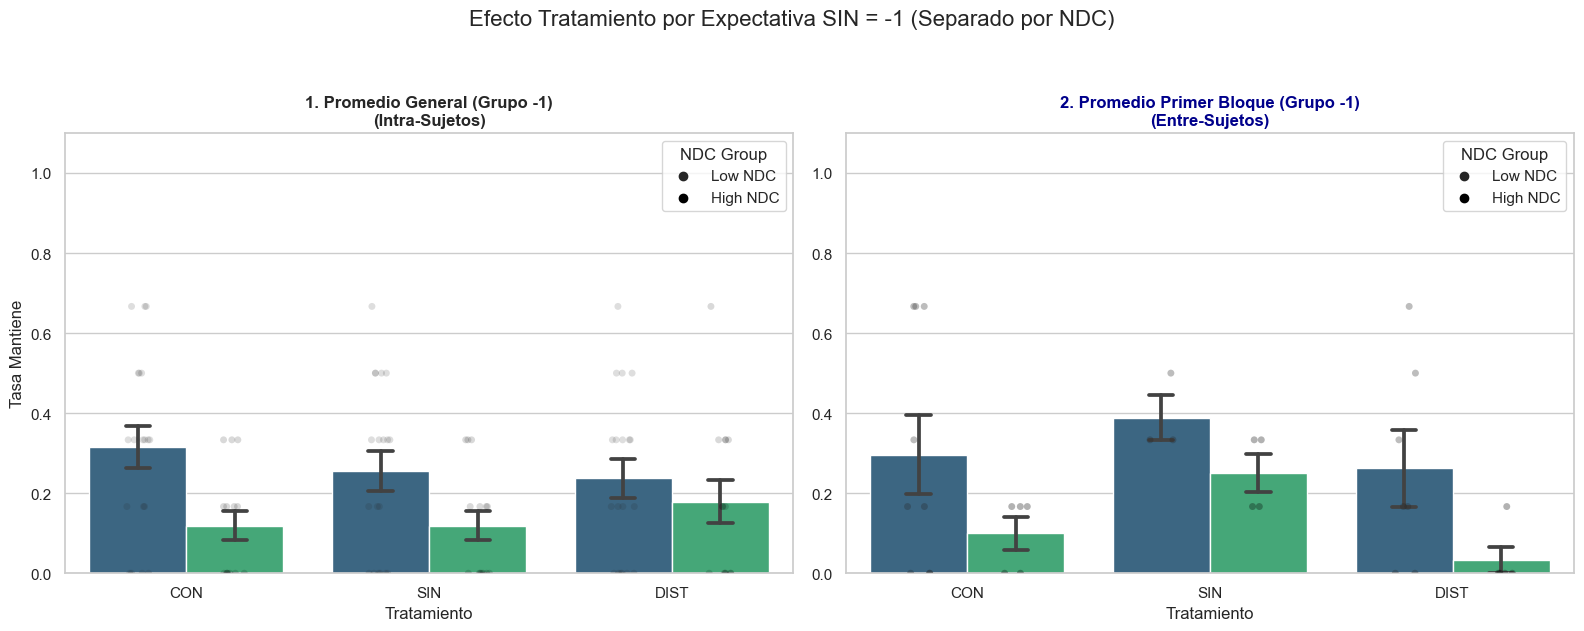

--- RESULTADOS GRUPO -1 (Desglosado por NDC) ---

1. Intra-sujetos (Resumen):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      14  0.119  0.037
            Low NDC       19  0.316  0.052
SIN         High NDC      14  0.119  0.037
            Low NDC       19  0.254  0.050
DIST        High NDC      14  0.179  0.054
            Low NDC       19  0.237  0.048

2. Entre-sujetos (Primer Bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       5  0.100  0.041
            Low NDC        9  0.296  0.099
SIN         High NDC       4  0.250  0.048
            Low NDC        3  0.389  0.056
DIST        High NDC       5  0.033  0.033
            Low NDC        7  0.262  0.095



 ANÁLISIS PARA: expectativa_sin_num = 0


C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


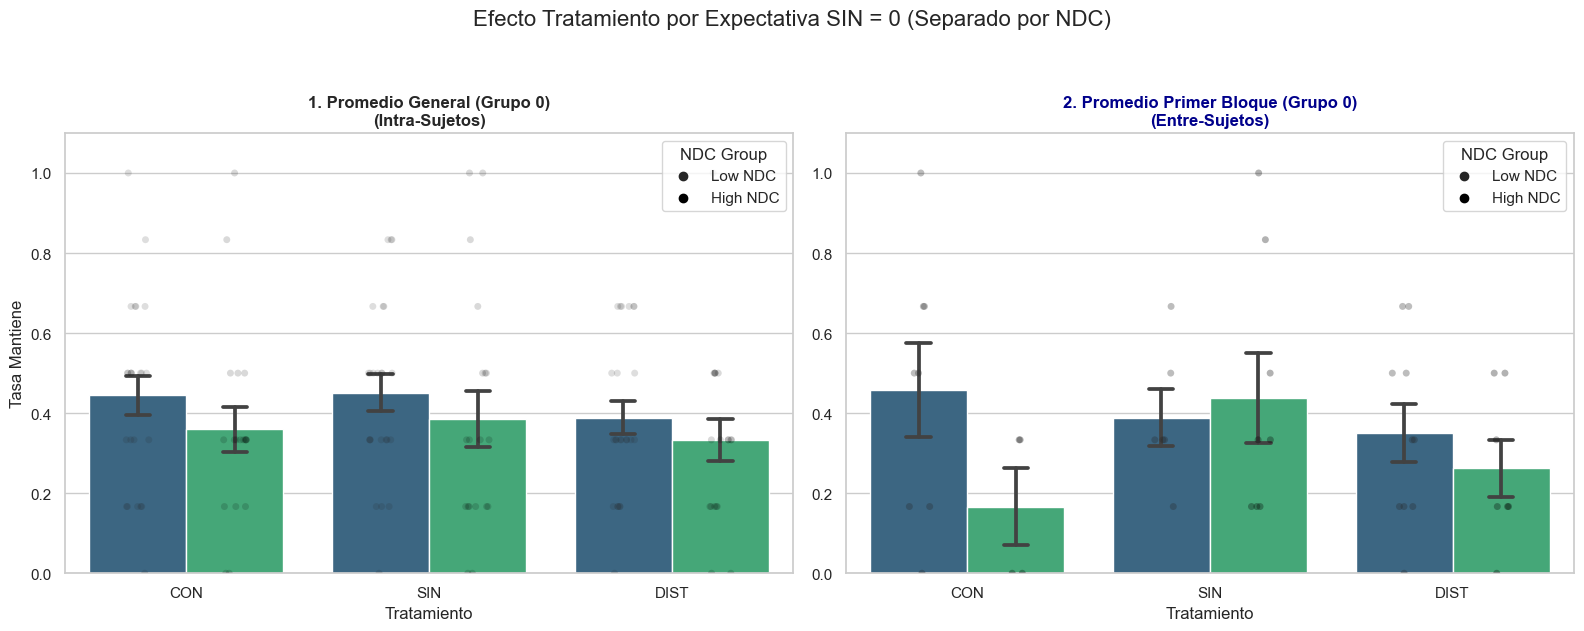

--- RESULTADOS GRUPO 0 (Desglosado por NDC) ---

1. Intra-sujetos (Resumen):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      19  0.360  0.056
            Low NDC       24  0.444  0.049
SIN         High NDC      19  0.386  0.070
            Low NDC       24  0.451  0.045
DIST        High NDC      19  0.333  0.053
            Low NDC       24  0.389  0.041

2. Entre-sujetos (Primer Bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       4  0.167  0.096
            Low NDC        8  0.458  0.117
SIN         High NDC       8  0.437  0.113
            Low NDC        6  0.389  0.070
DIST        High NDC       7  0.262  0.071
            Low NDC       10  0.350  0.072



 ANÁLISIS PARA: expectativa_sin_num = 1


C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


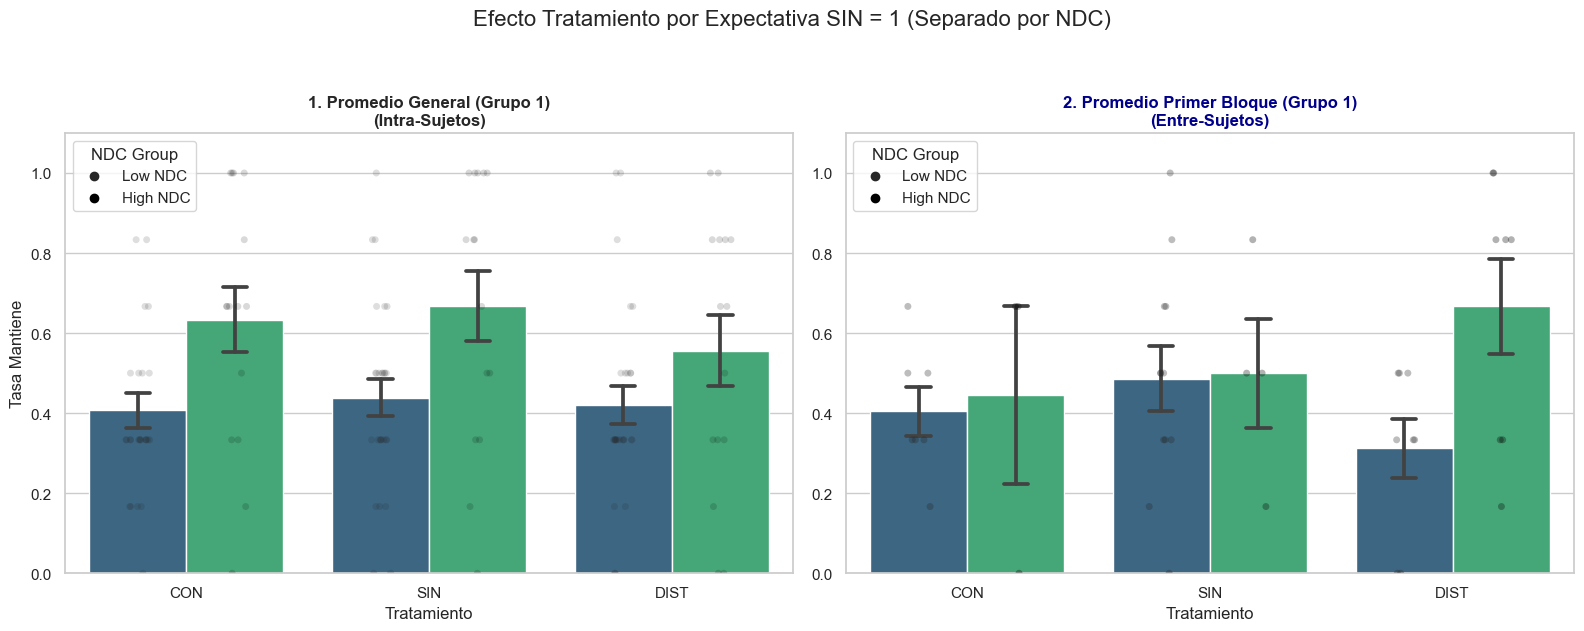

--- RESULTADOS GRUPO 1 (Desglosado por NDC) ---

1. Intra-sujetos (Resumen):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      15  0.633  0.082
            Low NDC       27  0.407  0.044
SIN         High NDC      15  0.667  0.088
            Low NDC       27  0.438  0.046
DIST        High NDC      15  0.556  0.089
            Low NDC       27  0.420  0.047

2. Entre-sujetos (Primer Bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       3  0.444  0.222
            Low NDC        7  0.405  0.061
SIN         High NDC       4  0.500  0.136
            Low NDC       12  0.486  0.081
DIST        High NDC       8  0.667  0.118
            Low NDC        8  0.312  0.073




In [5]:
# --- LIMPIEZA DE DUPLICADOS EN df_long ---
df_long = pd.read_csv('df_long.csv')
df_long = df_long.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()
df_resumen = pd.read_csv('Base_Resumen_Sujetos.csv')
# 2. Preprocesamiento
df_long['Tratamiento'] = df_long['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# --- CLASIFICACIÓN NDC (High vs Low) ---
# Calculamos la mediana basada en los sujetos únicos (usando df_resumen para evitar sesgo por número de filas)
if 'NDC_Score' in df_resumen.columns:
    median_ndc = df_resumen['NDC_Score'].median()
    print(f"Mediana NDC Score: {median_ndc}")

    # Función para clasificar
    def classify_ndc(score):
        return 'High NDC' if score > median_ndc else 'Low NDC'

    # Aplicar a df_resumen
    df_resumen['NDC_Group'] = df_resumen['NDC_Score'].apply(classify_ndc)
    
    # Aplicar a df_long (asegurando que cada sujeto tenga su score, que ya está en df_long)
    df_long['NDC_Group'] = df_long['NDC_Score'].apply(classify_ndc)
    
    print("Clasificación NDC completada.")
    print(df_resumen['NDC_Group'].value_counts())
else:
    print("Error: No se encontró la columna 'NDC_Score'")

# Definir columna de agrupación
col_grupo = 'expectativa_sin_num'

# Verificar que la columna exista
if col_grupo not in df_long.columns:
    print(f"Error: {col_grupo} no está en df_long")
else:
    grupos = sorted(df_long[col_grupo].dropna().unique())
    print(f"Grupos encontrados en {col_grupo}: {grupos}")

    # Iterar por cada grupo
    for grupo in grupos:
        print(f"\n{'='*80}")
        print(f" ANÁLISIS PARA: {col_grupo} = {grupo}")
        print(f"{'='*80}")
        
        # Filtrar df_long para este grupo
        df_long_grupo = df_long[df_long[col_grupo] == grupo].copy()
        ids_grupo = df_long_grupo['ID_Sujeto'].unique()
        
        # Filtrar df_resumen para los mismos sujetos (para consistencia)
        df_resumen_grupo = df_resumen[df_resumen['ID_Sujeto'].isin(ids_grupo)].copy()
        
        # --- PREPARACIÓN DE DATOS ---
        
        # A. Panel 1: Promedio General (Desde df_resumen)
        # Melt, pero mantenemos NDC_Group
        df_panel1 = df_resumen_grupo.melt(
            id_vars=['ID_Sujeto', 'NDC_Group'], 
            value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
            var_name='Tratamiento', 
            value_name='Mantiene'
        )
        df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')
        
        # B. Panel 2: Promedio Primer Tratamiento (Desde df_long)
        # Agrupamos por Sujeto, Tratamiento Y NDC_Group
        df_panel2 = df_long_grupo[df_long_grupo['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento', 'NDC_Group'])['Mantiene'].mean().reset_index()
        
        # --- VISUALIZACIÓN ---
        orden = ['CON', 'SIN', 'DIST']
        hue_order = ['Low NDC', 'High NDC'] # Orden consistente
        sns.set_theme(style="whitegrid")
        
        # Configuramos solo 2 columnas
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Panel 1
        sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                    palette='viridis', errorbar='se', capsize=.1, ax=axes[0])
        sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                      color='black', alpha=0.15, jitter=True, dodge=True, ax=axes[0])
        
        # Limpiar leyenda duplicada del stripplot
        handles, labels = axes[0].get_legend_handles_labels()
        # Tomamos solo los primeros 2 (las barras)
        axes[0].legend(handles[:2], labels[:2], title='NDC Group')
        
        axes[0].set_title(f'1. Promedio General (Grupo {grupo})\n(Intra-Sujetos)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Tasa Mantiene')
        axes[0].set_ylim(0, 1.1)
        
        # Panel 2
        sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                    palette='viridis', errorbar='se', capsize=.1, ax=axes[1])
        sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                      color='black', alpha=0.3, jitter=True, dodge=True, ax=axes[1])
        
        # Limpiar leyenda panel 2
        handles2, labels2 = axes[1].get_legend_handles_labels()
        axes[1].legend(handles2[:2], labels2[:2], title='NDC Group')

        axes[1].set_title(f'2. Promedio Primer Bloque (Grupo {grupo})\n(Entre-Sujetos)', fontsize=12, fontweight='bold', color='darkblue')
        axes[1].set_ylabel('')
        axes[1].set_ylim(0, 1.1)
        
        plt.suptitle(f'Efecto Tratamiento por Expectativa SIN = {grupo} (Separado por NDC)', fontsize=16, y=1.05)
        plt.tight_layout()
        filename = f'panel_doble_expsin_{grupo}_ndc.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        # --- TABLAS ---
        print(f"--- RESULTADOS GRUPO {grupo} (Desglosado por NDC) ---")
        print("\n1. Intra-sujetos (Resumen):")
        print(df_panel1.groupby(['Tratamiento', 'NDC_Group'])['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden, level=0).round(3))
        
        print("\n2. Entre-sujetos (Primer Bloque):")
        print(df_panel2.groupby(['Tratamiento', 'NDC_Group'])['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden, level=0).round(3))
        print("\n")